# Plot an Experiment

## Imports

In [1]:
from pathlib import Path
import re
import logging

import numpy as np
import pandas as pd
import pingouin
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm, Normalize
from matplotlib.cm import ScalarMappable

from gulp2p.preproc.tiff import Tiff
from gulp2p.preproc.experiment import Experiment, create_expt_df
from gulp2p.preproc import utils, imaging, behavior, trial as tr
from gulp2p.viz import plotting

from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42
rcParams['svg.fonttype'] = "none"

### Logging config

In [2]:
log_level = logging.DEBUG    # log levels: DEBUG, INFO, WARNING, ERROR, CRITICAL
log_format = "{asctime} - {levelname} - {name} - [{filename} {funcName}() {lineno}] - {message}"
logging.basicConfig(format=log_format, level=log_level, style="{") 

logging.getLogger("gulp2p").setLevel(logging.DEBUG)
logging.getLogger("matplotlib.font_manager").setLevel(logging.INFO)
logger = logging.getLogger(__name__)

## Select Data

### Functions:

In [3]:
CELL_TYPES = ["DR015", "DR018", "DR019"]

GENETIC_TOOLS = ["iGluSnFR"]

### Create trial dataframe:

In [4]:
TIFF_FOLDER = Path(r"Z:\2PImaging\Kerstin\MIMS")

trial_df = tr.create_trial_df(TIFF_FOLDER, CELL_TYPES, GENETIC_TOOLS)

In [5]:
trial_df.head()

,path,date,line,cell_type,genetic_tool,fly,trial
0,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,1
1,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,2
2,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,3
3,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,4
4,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,1


### Sort into experiments:

In [6]:
expt_df = create_expt_df(trial_df, CELL_TYPES, GENETIC_TOOLS)

2024-09-12 11:41:52,478 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00001.tif
2024-09-12 11:41:52,484 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00002.tif
2024-09-12 11:41:52,490 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00003.tif
2024-09-12 11:41:52,496 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00004.tif
2024-09-12 11:41:52,502 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_Stripe_00001.tif
2024-09-12 11:41:52,509 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not pr

In [7]:
expt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   expt_name         40 non-null     object
 1   trial_paths       40 non-null     object
 2   date              40 non-null     object
 3   line              39 non-null     object
 4   cell_type         39 non-null     object
 5   genetic_tool      39 non-null     object
 6   fly               40 non-null     int64 
 7   trials            40 non-null     object
 8   proc_trial_count  40 non-null     int64 
dtypes: int64(2), object(7)
memory usage: 2.9+ KB


In [8]:
expt_df.tail()

,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count
35,20240626_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,2
36,20240626_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5
37,20240702_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240702\20240702_D...,20240702,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,14
38,20240708_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,3
39,20240708_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5


### Load data

In [9]:
# Select only experiments that include processed trials
processed_expt_df = expt_df[expt_df['proc_trial_count'] > 0]

In [10]:
# Create Experiment objects
processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)

2024-09-12 11:42:05,448 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240116_DR018xiGluSnFr_Fly1_00001 is missing synced_df, removing from Experiment.
2024-09-12 11:42:05,454 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240117_DR019xiGluSnFr_Fly2_00004 is missing synced_df, removing from Experiment.
2024-09-12 11:42:05,496 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240626_DR015xiGluSnfR_fly2_00002 is missing synced_df, removing from Experiment.
C:\Users\ahshenas\AppData\Local\Temp\ipykernel_10852\3279863305.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)


In [11]:
# Remove empty experiments:
empty_expt_idxs = []
for idx, expt in processed_expt_df['expt'].items():
    if expt.synced_df is None:
        empty_expt_idxs.append(idx)
processed_expt_df = processed_expt_df.drop(index=empty_expt_idxs)

In [12]:
print(f"number of processed experiments: {len(processed_expt_df)}")
processed_expt_df.head()

number of processed experiments: 23


,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count,expt
10,20231206_DR018xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231206\20231206_D...,20231206,DR018xiGluSnFr,DR018,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,10,<gulp2p.preproc.experiment.Experiment object a...
12,20231207_DR019xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231207\20231207_D...,20231207,DR019xiGluSnFr,DR019,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,9,<gulp2p.preproc.experiment.Experiment object a...
13,20231207_DR019xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231207\20231207_D...,20231207,DR019xiGluSnFr,DR019,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,3,<gulp2p.preproc.experiment.Experiment object a...
14,20231212_DR018xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231212\20231212_D...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,11,<gulp2p.preproc.experiment.Experiment object a...
15,20231212_DR018xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231212\20231212_D...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,3,<gulp2p.preproc.experiment.Experiment object a...


## Plot Experiment

In [34]:
# Select Experiment
# expt = processed_expt_df[processed_expt_df['expt_name'] == '20231212_DR018xiGluSnFr_Fly2']['expt'].iloc[0]
expt = processed_expt_df.iloc[6]['expt']

2024-09-12 11:44:31,022 - DEBUG - matplotlib.colorbar - [colorbar.py _get_ticker_locator_formatter() 859] - locator: <matplotlib.ticker.AutoLocator object at 0x00000279DD60C280>


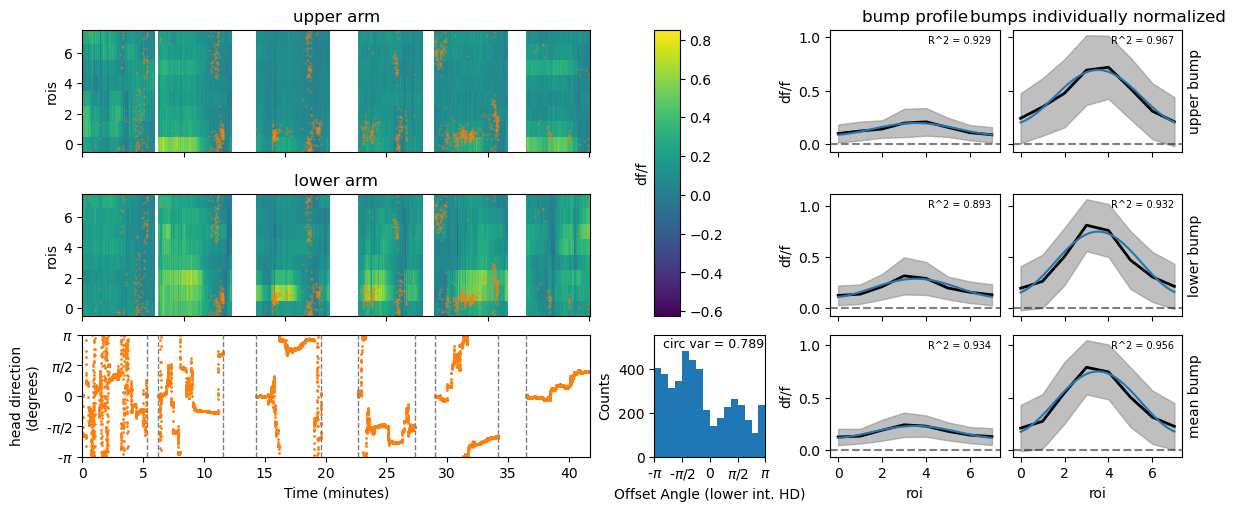

In [35]:
fig, axd = plotting.plot_expt(expt)
# axd['head_direction_offset'].set_xlim([-6,6])

In [36]:
import gulp2p.analysis.head_direction as hd

hd_offset = hd.get_hd_offset(expt, mode='upper')

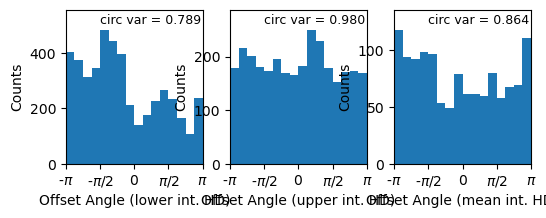

In [37]:
fig, axs = plt.subplots(1,3, figsize=(6,2))
for i, mode in enumerate(['lower', 'upper', 'mean']):
    plotting.plot_hd_offset_histogram(expt, axs[i], nbins=16, mode=mode)

In [38]:
max(hd_offset)

nan

In [39]:
# mask = (hd_offset >=  np.pi)
# hd_offset[mask] -= np.pi

In [40]:
hd_offset = pingouin.convert_angles(hd_offset, low=0, high=2*np.pi)